# Pertemuan 6: Ensemble Methods - Random Forest & Gradient Boosting

## Identitas
- Nama: MUH. ALI IMRAN
- NIM: 105841113523
- Program Studi: Informatika
- Mata Kuliah: Applied Machine Learning

## Tujuan
1. Memahami konsep ensemble learning.
2. Mengimplementasikan Random Forest untuk classification dan regression.
3. Memahami Gradient Boosting.
4. Melakukan feature importance analysis.
5. Melakukan hyperparameter tuning.
6. Membandingkan single model dengan ensemble models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)

from sklearn.datasets import (
    load_breast_cancer,
    load_diabetes,
    make_classification
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Library berhasil diimpor!")

Library berhasil diimpor!


In [2]:
# Load dataset Breast Cancer
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print("=== DATASET BREAST CANCER ===")
print(f"Jumlah data   : {X.shape[0]}")
print(f"Jumlah fitur  : {X.shape[1]}")
print(f"Nama kelas    : {cancer.target_names}")
print(f"Distribusi kelas:")
print(pd.Series(y).value_counts().sort_index())

=== DATASET BREAST CANCER ===
Jumlah data   : 569
Jumlah fitur  : 30
Nama kelas    : ['malignant' 'benign']
Distribusi kelas:
0    212
1    357
Name: count, dtype: int64


In [3]:
# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== PEMBAGIAN DATA ===")
print(f"Data training : {X_train.shape[0]}")
print(f"Data testing  : {X_test.shape[0]}")

=== PEMBAGIAN DATA ===
Data training : 455
Data testing  : 114


In [4]:
# Model tunggal: Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== DECISION TREE ===")
print(f"Accuracy  : {acc_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")

=== DECISION TREE ===
Accuracy  : 0.9123
Precision : 0.9559
Recall    : 0.9028
F1-Score  : 0.9286


In [5]:
# Menguji beberapa jumlah trees
n_estimators_range = [10, 50, 100, 200]

rf_results = []

for n_est in n_estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        random_state=42,
        n_jobs=-1
    )
    
    rf_temp.fit(X_train, y_train)
    y_pred = rf_temp.predict(X_test)
    
    rf_results.append({
        'n_estimators': n_est,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

rf_results_df = pd.DataFrame(rf_results)

print("=== RANDOM FOREST RESULTS ===")
print(rf_results_df.to_string(index=False))

=== RANDOM FOREST RESULTS ===
 n_estimators  Accuracy  Precision   Recall  F1-Score
           10  0.938596   0.957746 0.944444  0.951049
           50  0.956140   0.958904 0.972222  0.965517
          100  0.956140   0.958904 0.972222  0.965517
          200  0.956140   0.958904 0.972222  0.965517


In [6]:
# Membandingkan Decision Tree dengan Random Forest terbaik
best_n = rf_results_df.loc[
    rf_results_df['Accuracy'].idxmax(), 'n_estimators'
]

rf = RandomForestClassifier(
    n_estimators=int(best_n),
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [acc_dt, acc_rf],
    'Precision': [precision_dt, precision_rf],
    'Recall': [recall_dt, recall_rf],
    'F1-Score': [f1_dt, f1_rf]
})

print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))
print(f"\nJumlah trees terbaik: {int(best_n)}")

=== MODEL COMPARISON ===
        Model  Accuracy  Precision   Recall  F1-Score
Decision Tree  0.912281   0.955882 0.902778  0.928571
Random Forest  0.956140   0.958904 0.972222  0.965517

Jumlah trees terbaik: 50


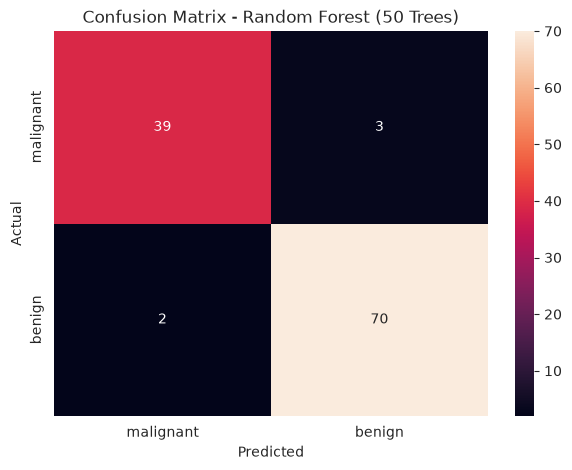

Classification Report - Random Forest
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [7]:
# Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Random Forest ({int(best_n)} Trees)')
plt.show()

print("Classification Report - Random Forest")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=cancer.target_names
    )
)

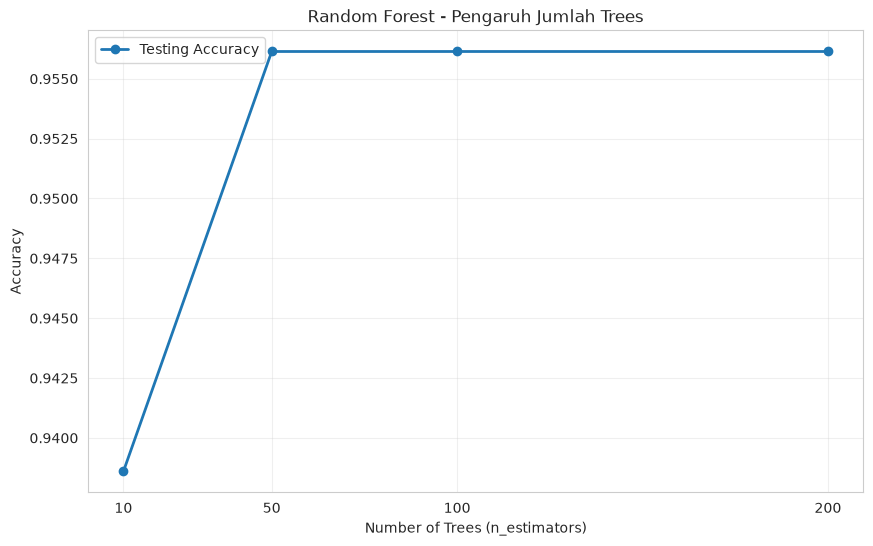

In [8]:
# Visualisasi pengaruh jumlah trees
plt.figure(figsize=(10, 6))

plt.plot(
    rf_results_df['n_estimators'],
    rf_results_df['Accuracy'],
    'o-',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest - Pengaruh Jumlah Trees')
plt.xticks(n_estimators_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Analisis Tugas 1

Random Forest dibandingkan dengan satu Decision Tree menggunakan dataset Breast Cancer.

Random Forest menggunakan beberapa Decision Tree sehingga hasil prediksi biasanya lebih stabil dibandingkan satu Decision Tree. Jumlah trees diuji pada nilai 10, 50, 100, dan 200.

Jumlah trees yang menghasilkan testing accuracy paling tinggi dipilih sebagai jumlah trees yang optimal pada percobaan ini. Penambahan jumlah trees tidak selalu meningkatkan accuracy secara besar karena setelah jumlah tertentu peningkatannya cenderung semakin kecil.

Dari percobaan ini dapat dilihat bahwa Random Forest dapat menjadi model ensemble yang lebih stabil dibandingkan satu Decision Tree.

In [9]:
# Gradient Boosting dengan parameter default
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("=== GRADIENT BOOSTING DEFAULT ===")
print(f"Accuracy  : {acc_gb:.4f}")
print(f"Precision : {precision_gb:.4f}")
print(f"Recall    : {recall_gb:.4f}")
print(f"F1-Score  : {f1_gb:.4f}")

=== GRADIENT BOOSTING DEFAULT ===
Accuracy  : 0.9561
Precision : 0.9467
Recall    : 0.9861
F1-Score  : 0.9660


In [10]:
# Menguji berbagai learning rate
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]

gb_lr_results = []

for lr in learning_rates:
    gb_temp = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    
    gb_temp.fit(X_train, y_train)
    
    y_pred = gb_temp.predict(X_test)
    
    gb_lr_results.append({
        'Learning Rate': lr,
        'Train Accuracy': accuracy_score(
            y_train, gb_temp.predict(X_train)
        ),
        'Test Accuracy': accuracy_score(
            y_test, y_pred
        )
    })

gb_lr_df = pd.DataFrame(gb_lr_results)

print("=== LEARNING RATE RESULTS ===")
print(gb_lr_df.to_string(index=False))

=== LEARNING RATE RESULTS ===
 Learning Rate  Train Accuracy  Test Accuracy
          0.01        0.986813       0.921053
          0.05        1.000000       0.947368
          0.10        1.000000       0.956140
          0.50        1.000000       0.956140
          1.00        1.000000       0.956140


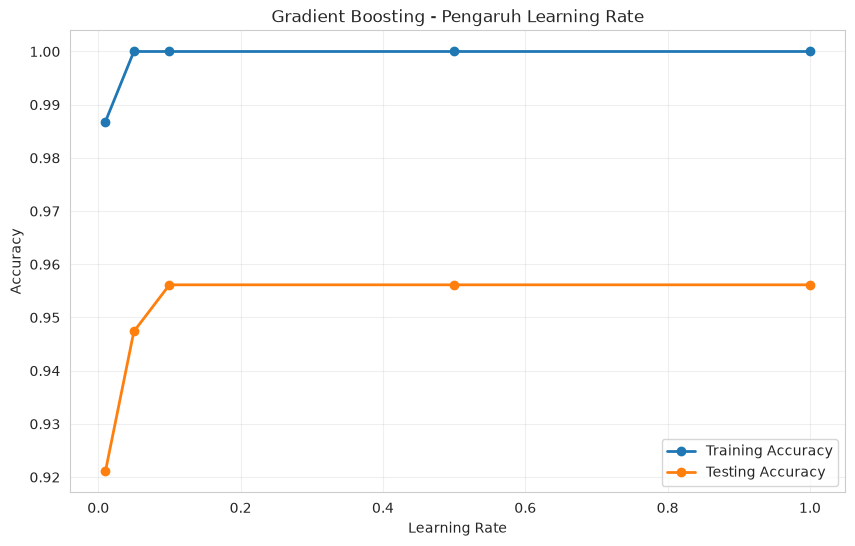

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    gb_lr_df['Learning Rate'],
    gb_lr_df['Train Accuracy'],
    'o-',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    gb_lr_df['Learning Rate'],
    gb_lr_df['Test Accuracy'],
    'o-',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting - Pengaruh Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

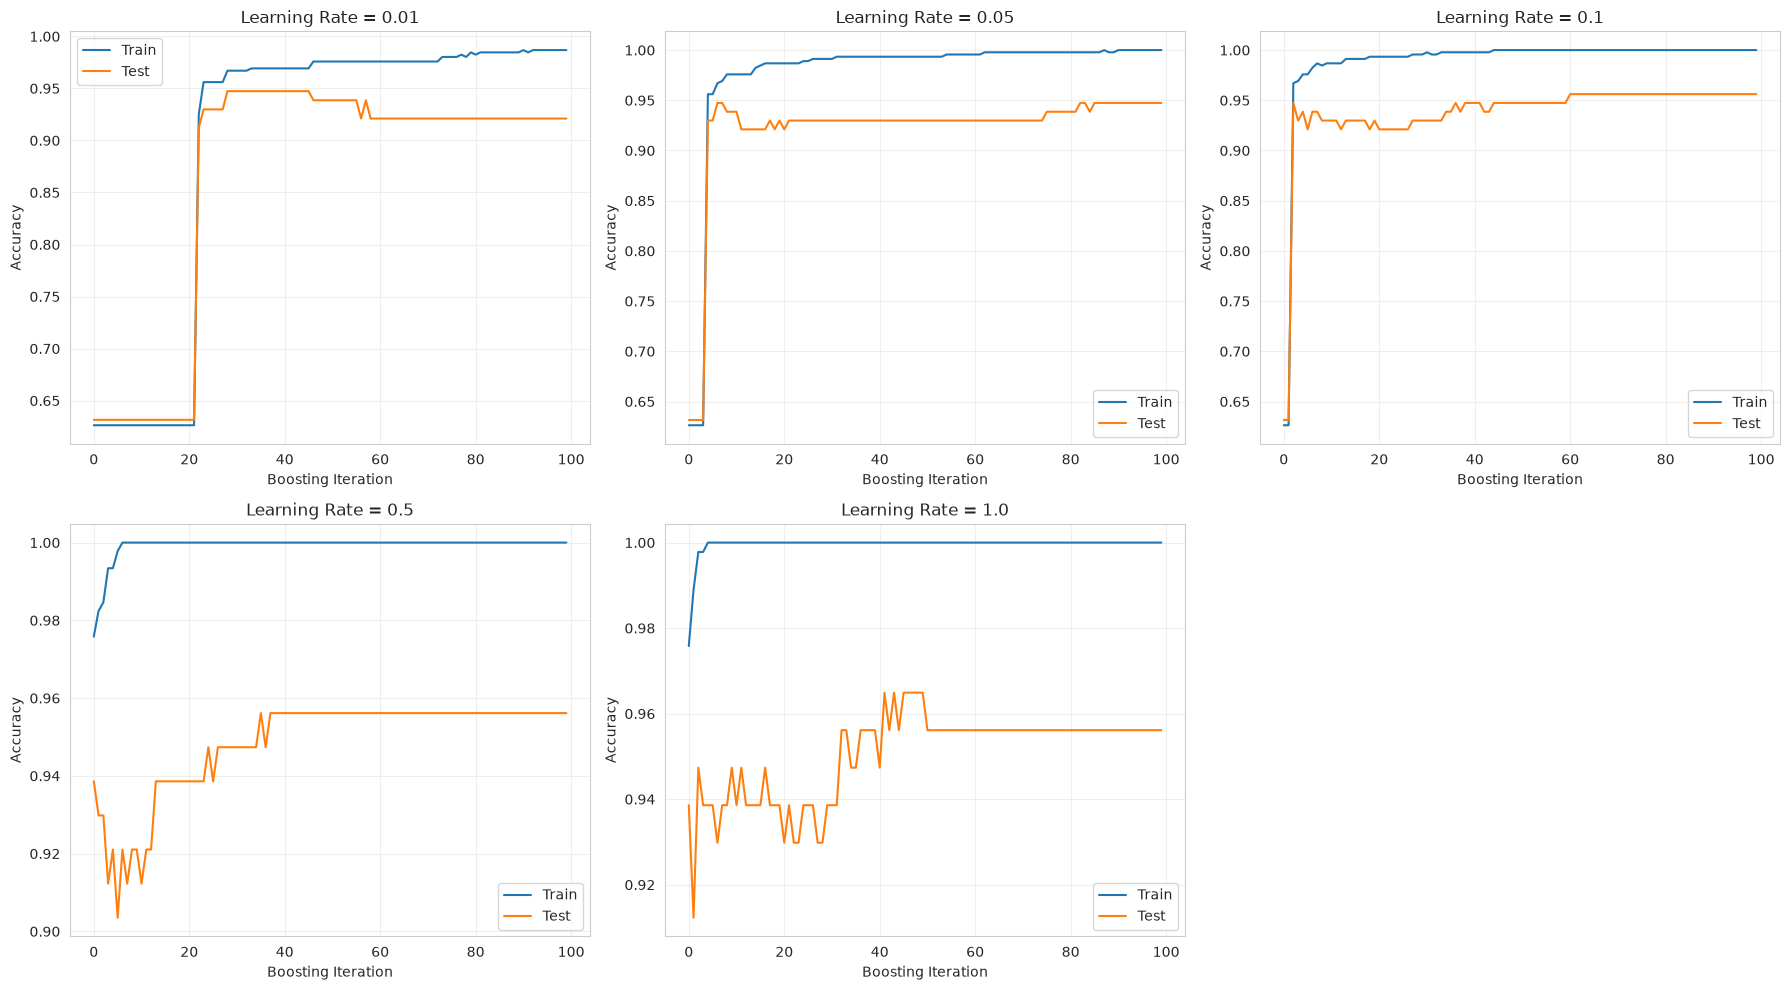

In [12]:
# Melihat proses pembelajaran untuk setiap learning rate
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, lr in enumerate(learning_rates):
    gb_temp = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    
    gb_temp.fit(X_train, y_train)
    
    train_scores = []
    test_scores = []
    
    for pred in gb_temp.staged_predict(X_train):
        train_scores.append(accuracy_score(y_train, pred))
    
    for pred in gb_temp.staged_predict(X_test):
        test_scores.append(accuracy_score(y_test, pred))
    
    axes[idx].plot(train_scores, label='Train')
    axes[idx].plot(test_scores, label='Test')
    axes[idx].set_title(f'Learning Rate = {lr}')
    axes[idx].set_xlabel('Boosting Iteration')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Menghapus subplot yang tidak digunakan
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [13]:
best_lr_row = gb_lr_df.loc[
    gb_lr_df['Test Accuracy'].idxmax()
]

print("=== LEARNING RATE TERBAIK ===")
print(f"Learning Rate     : {best_lr_row['Learning Rate']}")
print(f"Train Accuracy    : {best_lr_row['Train Accuracy']:.4f}")
print(f"Test Accuracy     : {best_lr_row['Test Accuracy']:.4f}")

print("\nInterpretasi:")
print("Learning rate kecil membuat pembelajaran lebih lambat.")
print("Learning rate terlalu besar dapat membuat model belajar terlalu agresif.")
print("Learning rate yang baik memberikan keseimbangan antara training dan testing accuracy.")

=== LEARNING RATE TERBAIK ===
Learning Rate     : 0.1
Train Accuracy    : 1.0000
Test Accuracy     : 0.9561

Interpretasi:
Learning rate kecil membuat pembelajaran lebih lambat.
Learning rate terlalu besar dapat membuat model belajar terlalu agresif.
Learning rate yang baik memberikan keseimbangan antara training dan testing accuracy.


In [14]:
# Menguji berbagai max_depth
max_depths = [2, 3, 5, 7, 10]

gb_depth_results = []

for depth in max_depths:
    gb_temp = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    
    gb_temp.fit(X_train, y_train)
    
    y_pred = gb_temp.predict(X_test)
    
    gb_depth_results.append({
        'Max Depth': depth,
        'Train Accuracy': accuracy_score(
            y_train, gb_temp.predict(X_train)
        ),
        'Test Accuracy': accuracy_score(
            y_test, y_pred
        )
    })

gb_depth_df = pd.DataFrame(gb_depth_results)

print("=== MAX DEPTH RESULTS ===")
print(gb_depth_df.to_string(index=False))

=== MAX DEPTH RESULTS ===
 Max Depth  Train Accuracy  Test Accuracy
         2             1.0       0.947368
         3             1.0       0.956140
         5             1.0       0.938596
         7             1.0       0.912281
        10             1.0       0.912281


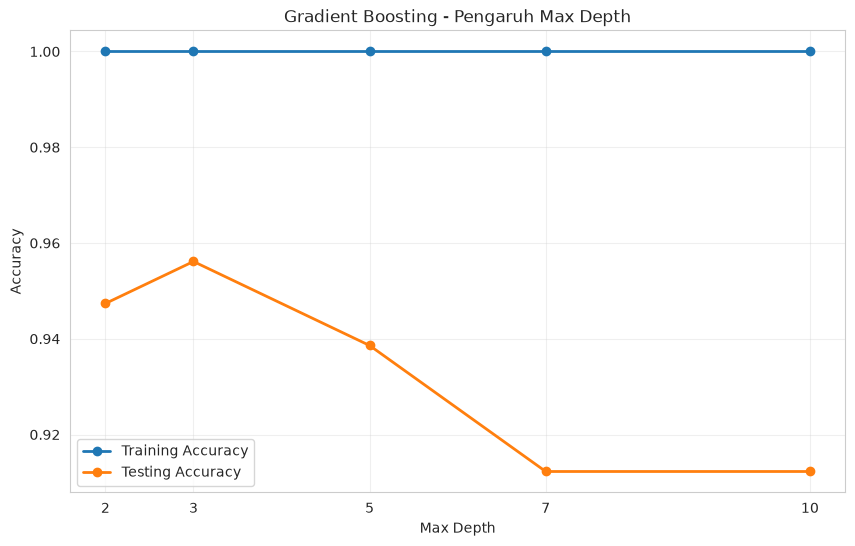

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    gb_depth_df['Max Depth'],
    gb_depth_df['Train Accuracy'],
    'o-',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    gb_depth_df['Max Depth'],
    gb_depth_df['Test Accuracy'],
    'o-',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting - Pengaruh Max Depth')
plt.xticks(max_depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

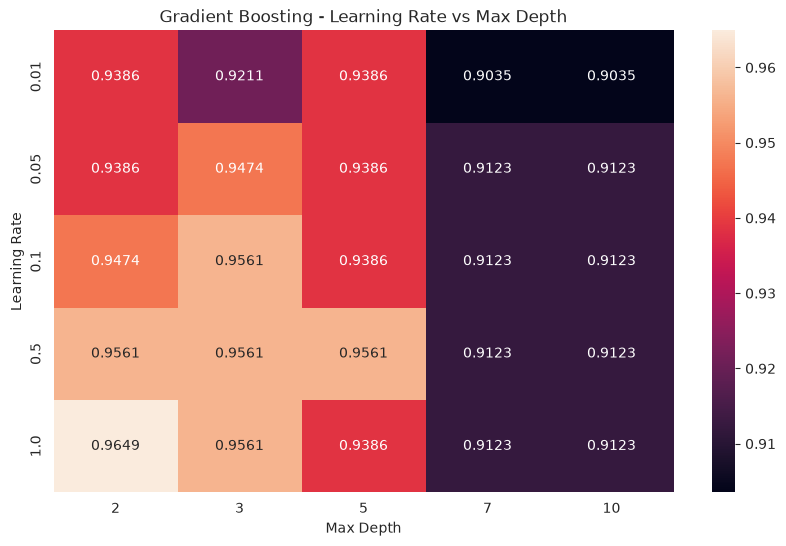

In [16]:
# Menguji kombinasi learning rate dan max_depth
heatmap_results = []

for lr in learning_rates:
    for depth in max_depths:
        model = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=lr,
            max_depth=depth,
            random_state=42
        )
        
        model.fit(X_train, y_train)
        
        heatmap_results.append({
            'Learning Rate': lr,
            'Max Depth': depth,
            'Test Accuracy': accuracy_score(
                y_test,
                model.predict(X_test)
            )
        })

heatmap_df = pd.DataFrame(heatmap_results)

heatmap_pivot = heatmap_df.pivot(
    index='Learning Rate',
    columns='Max Depth',
    values='Test Accuracy'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.4f'
)

plt.title('Gradient Boosting - Learning Rate vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Learning Rate')
plt.show()

In [17]:
best_gb = heatmap_df.loc[
    heatmap_df['Test Accuracy'].idxmax()
]

print("=== PARAMETER TERBAIK ===")
print(f"Learning Rate : {best_gb['Learning Rate']}")
print(f"Max Depth     : {best_gb['Max Depth']}")
print(f"Test Accuracy : {best_gb['Test Accuracy']:.4f}")

=== PARAMETER TERBAIK ===
Learning Rate : 1.0
Max Depth     : 2.0
Test Accuracy : 0.9649


## Analisis Tugas 2

Gradient Boosting diuji menggunakan beberapa nilai learning rate dan max_depth.

Learning rate yang kecil membuat proses pembelajaran lebih lambat sehingga model membutuhkan lebih banyak boosting iterations. Learning rate yang lebih besar membuat model belajar lebih cepat, tetapi jika terlalu besar dapat meningkatkan risiko overfitting.

Max depth juga memengaruhi kompleksitas model. Depth yang terlalu kecil dapat menyebabkan model kurang mampu mempelajari pola data, sedangkan depth yang terlalu besar dapat membuat model terlalu kompleks.

Berdasarkan hasil percobaan, kombinasi learning rate dan max_depth dengan testing accuracy tertinggi dipilih sebagai parameter terbaik.

In [18]:
# ============================================
# TUGAS 3 - REGRESSION ENSEMBLE
# ============================================

diabetes = load_diabetes()

X_reg = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)
y_reg = pd.Series(diabetes.target, name="target")

print("Jumlah data:", X_reg.shape[0])
print("Jumlah fitur:", X_reg.shape[1])
print("\nNama fitur:")
print(list(X_reg.columns))

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("\nData training:", X_reg_train.shape)
print("Data testing :", X_reg_test.shape)

Jumlah data: 442
Jumlah fitur: 10

Nama fitur:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Data training: (353, 10)
Data testing : (89, 10)


In [19]:
# Membuat model
dt_reg = DecisionTreeRegressor(random_state=42)

rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

models_reg = {
    "Decision Tree": dt_reg,
    "Random Forest": rf_reg,
    "Gradient Boosting": gb_reg
}

results_reg = []

for name, model in models_reg.items():
    model.fit(X_reg_train, y_reg_train)
    pred = model.predict(X_reg_test)

    r2 = r2_score(y_reg_test, pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, pred))

    results_reg.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse
    })

results_reg_df = pd.DataFrame(results_reg)

print("Perbandingan Model Regression:")
display(results_reg_df)

Perbandingan Model Regression:


,Model,R2,RMSE
0,Decision Tree,0.060654,70.546423
1,Random Forest,0.442823,54.332408
2,Gradient Boosting,0.455050,53.732952


In [20]:
# Feature importance dari masing-masing model
feature_importance = pd.DataFrame({
    "Feature": X_reg.columns,
    "Decision Tree": dt_reg.feature_importances_,
    "Random Forest": rf_reg.feature_importances_,
    "Gradient Boosting": gb_reg.feature_importances_
})

print("Feature Importance:")
display(
    feature_importance.sort_values(
        "Random Forest",
        ascending=False
    )
)

Feature Importance:


,Feature,Decision Tree,Random Forest,Gradient Boosting
2,bmi,0.418232,0.355469,0.392691
8,s5,0.155795,0.230957,0.249562
3,bp,0.062494,0.088408,0.083410
9,s6,0.061930,0.071329,0.045556
0,age,0.064586,0.058642,0.049612
5,s2,0.053389,0.057227,0.061056
4,s1,0.083177,0.052784,0.038892
6,s3,0.063936,0.051339,0.036588
7,s4,0.029788,0.024213,0.030155
1,sex,0.006673,0.009633,0.012478


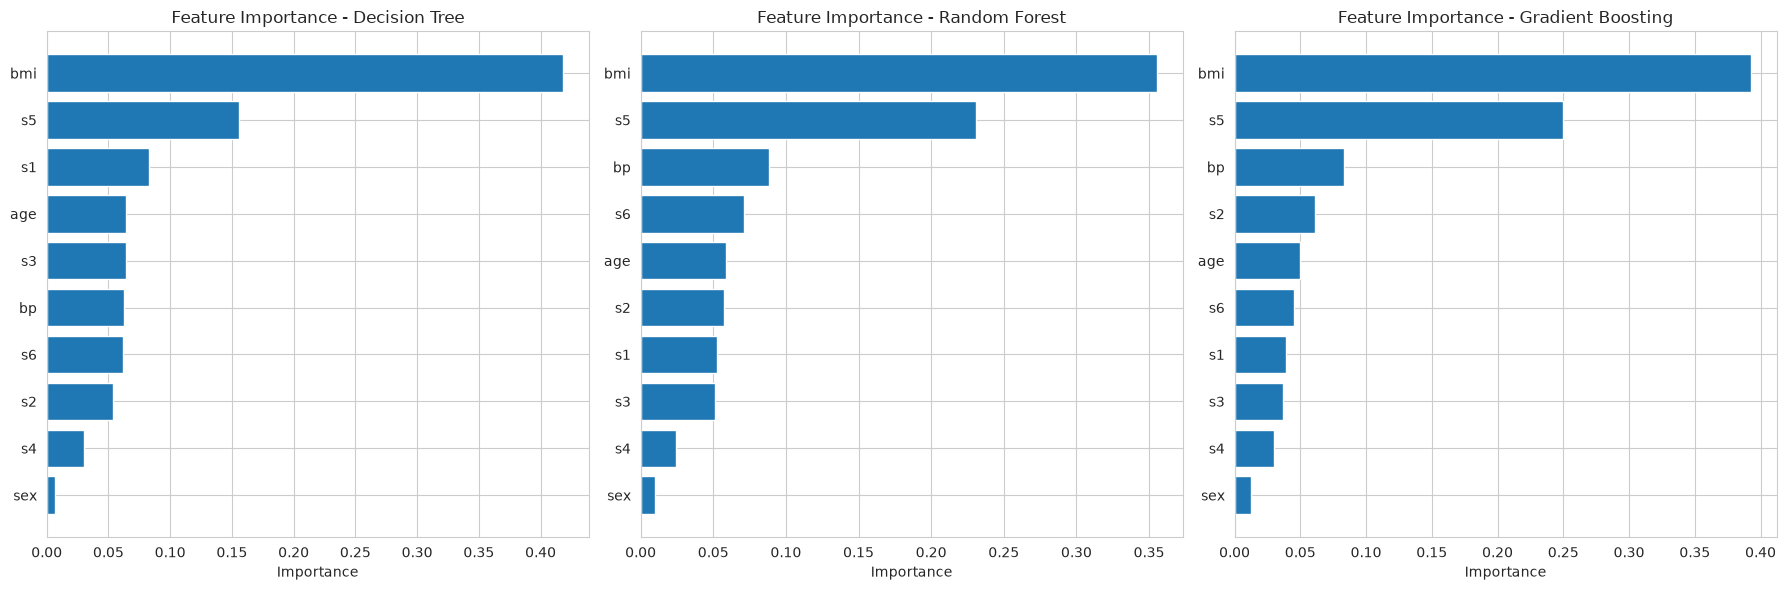

In [21]:
# Visualisasi feature importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, model_name in zip(
    axes,
    ["Decision Tree", "Random Forest", "Gradient Boosting"]
):
    data_plot = feature_importance.sort_values(
        model_name,
        ascending=True
    )

    ax.barh(
        data_plot["Feature"],
        data_plot[model_name]
    )

    ax.set_title(f"Feature Importance - {model_name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

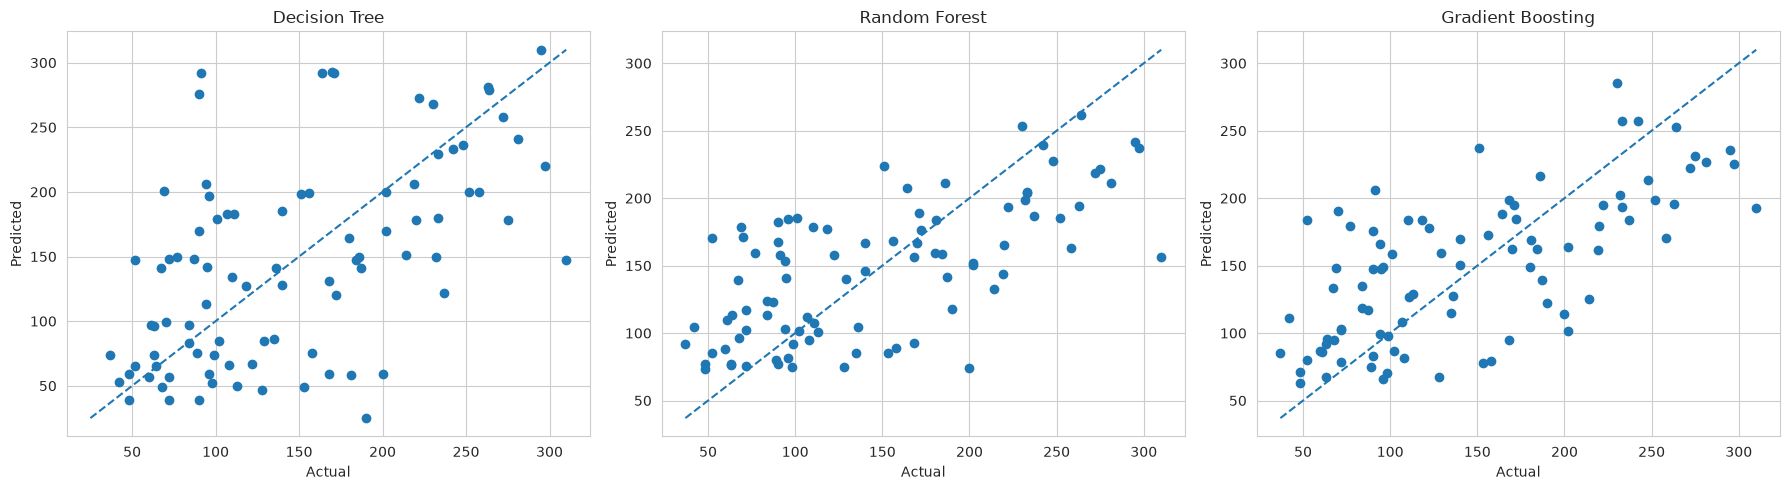

In [22]:
# Prediksi dari ketiga model
pred_dt = dt_reg.predict(X_reg_test)
pred_rf = rf_reg.predict(X_reg_test)
pred_gb = gb_reg.predict(X_reg_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predictions = {
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gb
}

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_reg_test, pred)

    min_val = min(y_reg_test.min(), pred.min())
    max_val = max(y_reg_test.max(), pred.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    ax.set_title(f"{name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# TUGAS 4 - CUSTOMER CHURN
# ============================================

np.random.seed(42)

n = 100

churn_data = pd.DataFrame({
    "tenure": np.random.randint(1, 60, n),
    "monthly_charges": np.random.randint(50, 150, n),
    "contract": np.random.choice(
        ["Bulanan", "Tahunan", "Dua Tahun"], n
    ),
    "internet": np.random.choice(
        ["DSL", "Fiber", "Tidak Ada"], n
    ),
    "churn": np.random.choice(
        ["Ya", "Tidak"], n
    )
})

print("Jumlah data:", len(churn_data))
display(churn_data.head())

Jumlah data: 100


,tenure,monthly_charges,contract,internet,churn
0,39,134,Bulanan,Fiber,Tidak
1,52,129,Bulanan,DSL,Ya
2,29,131,Bulanan,Tidak Ada,Tidak
3,15,102,Dua Tahun,DSL,Ya
4,43,73,Dua Tahun,Fiber,Tidak


Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   tenure           100 non-null    int64
 1   monthly_charges  100 non-null    int64
 2   contract         100 non-null    str  
 3   internet         100 non-null    str  
 4   churn            100 non-null    str  
dtypes: int64(2), str(3)
memory usage: 4.0 KB

Jumlah masing-masing Churn:
churn
Tidak    56
Ya       44
Name: count, dtype: int64


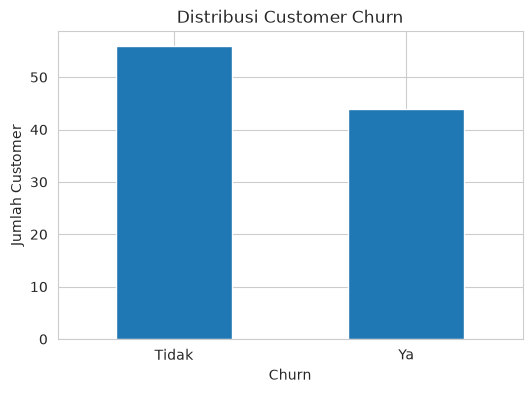

In [24]:
# Melihat informasi dataset
print("Informasi Dataset:")
churn_data.info()

print("\nJumlah masing-masing Churn:")
print(churn_data["churn"].value_counts())

# Visualisasi distribusi churn
plt.figure(figsize=(6, 4))
churn_data["churn"].value_counts().plot(kind="bar")
plt.title("Distribusi Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Customer")
plt.xticks(rotation=0)
plt.show()

In [25]:
# Memisahkan fitur dan target
X_churn = churn_data.drop("churn", axis=1)
y_churn = churn_data["churn"]

# One-hot encoding fitur kategorikal
X_churn = pd.get_dummies(
    X_churn,
    columns=["contract", "internet"],
    drop_first=True
)

# Mengubah target menjadi 0 dan 1
y_churn = y_churn.map({
    "Tidak": 0,
    "Ya": 1
})

print("Bentuk data setelah encoding:", X_churn.shape)
display(X_churn.head())

# Split data
X_churn_train, X_churn_test, y_churn_train, y_churn_test = train_test_split(
    X_churn,
    y_churn,
    test_size=0.2,
    random_state=42,
    stratify=y_churn
)

print("\nData training:", X_churn_train.shape)
print("Data testing :", X_churn_test.shape)

Bentuk data setelah encoding: (100, 6)


,tenure,monthly_charges,contract_Dua Tahun,contract_Tahunan,internet_Fiber,internet_Tidak Ada
0,39,134,False,False,True,False
1,52,129,False,False,False,False
2,29,131,False,False,False,True
3,15,102,True,False,False,False
4,43,73,True,False,True,False



Data training: (80, 6)
Data testing : (20, 6)


In [26]:
# Membuat tiga model
models_churn = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

churn_results = []

for name, model in models_churn.items():
    model.fit(X_churn_train, y_churn_train)

    pred = model.predict(X_churn_test)

    churn_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_churn_test, pred),
        "Precision": precision_score(y_churn_test, pred, zero_division=0),
        "Recall": recall_score(y_churn_test, pred, zero_division=0),
        "F1-Score": f1_score(y_churn_test, pred, zero_division=0)
    })

churn_results_df = pd.DataFrame(churn_results)

print("Perbandingan Model Customer Churn:")
display(churn_results_df)

Perbandingan Model Customer Churn:


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.70,0.714286,0.555556,0.625000
1,Random Forest,0.55,0.500000,0.444444,0.470588
2,Gradient Boosting,0.75,0.750000,0.666667,0.705882


In [27]:
# Cross Validation untuk membandingkan kestabilan model
cv_results = []

for name, model in models_churn.items():
    scores = cross_val_score(
        model,
        X_churn,
        y_churn,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print("Hasil 5-Fold Cross Validation:")
display(cv_results_df)

Hasil 5-Fold Cross Validation:


,Model,CV Mean Accuracy,CV Std
0,Decision Tree,0.57,0.128841
1,Random Forest,0.57,0.087178
2,Gradient Boosting,0.57,0.092736


In [28]:
# Menentukan model terbaik berdasarkan CV Mean Accuracy

best_model_name = cv_results_df.loc[
    cv_results_df["CV Mean Accuracy"].idxmax(),
    "Model"
]

print("Model terbaik berdasarkan Cross Validation:")
print(best_model_name)

print("\nHasil Cross Validation:")
display(
    cv_results_df.sort_values(
        "CV Mean Accuracy",
        ascending=False
    )
)

Model terbaik berdasarkan Cross Validation:
Decision Tree

Hasil Cross Validation:


,Model,CV Mean Accuracy,CV Std
0,Decision Tree,0.57,0.128841
1,Random Forest,0.57,0.087178
2,Gradient Boosting,0.57,0.092736


In [29]:
# ============================================
# HYPERPARAMETER TUNING RANDOM FOREST
# ============================================

rf_churn = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid_rf_churn = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5]
}

grid_rf_churn = GridSearchCV(
    rf_churn,
    param_grid_rf_churn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf_churn.fit(X_churn_train, y_churn_train)

print("Parameter terbaik:")
print(grid_rf_churn.best_params_)

print("\nCV Accuracy terbaik:")
print(grid_rf_churn.best_score_)

Parameter terbaik:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

CV Accuracy terbaik:
0.5875


In [30]:
# Evaluasi model terbaik hasil tuning
best_churn_model = grid_rf_churn.best_estimator_

final_pred = best_churn_model.predict(X_churn_test)

final_accuracy = accuracy_score(
    y_churn_test,
    final_pred
)

final_precision = precision_score(
    y_churn_test,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_churn_test,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_churn_test,
    final_pred,
    zero_division=0
)

print("=== HASIL EVALUASI FINAL ===")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_churn_test,
        final_pred,
        target_names=["Tidak Churn", "Churn"]
    )
)

=== HASIL EVALUASI FINAL ===
Accuracy : 0.6000
Precision: 0.5556
Recall   : 0.5556
F1-Score : 0.5556

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.64      0.64      0.64        11
       Churn       0.56      0.56      0.56         9

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



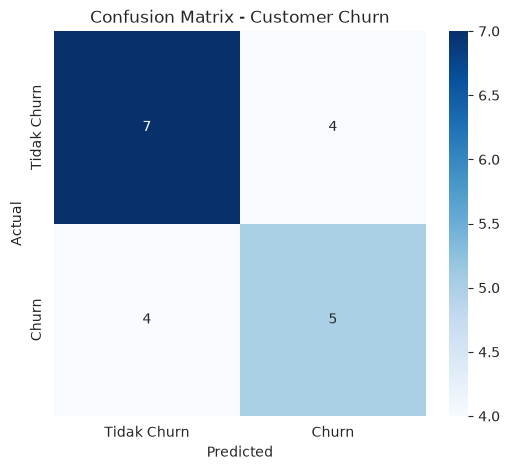

In [31]:
# Confusion Matrix
cm_churn = confusion_matrix(
    y_churn_test,
    final_pred
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_churn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Churn", "Churn"],
    yticklabels=["Tidak Churn", "Churn"]
)

plt.title("Confusion Matrix - Customer Churn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
# ============================================
# REKOMENDASI BISNIS
# ============================================

print("=== REKOMENDASI BISNIS ===")
print("""
1. Customer yang diprediksi akan churn perlu mendapat perhatian lebih awal.
2. Perusahaan dapat memberikan promo atau diskon kepada customer berisiko churn.
3. Customer dengan biaya bulanan tinggi dapat diberikan penawaran khusus.
4. Customer dengan masa berlangganan pendek perlu dipantau karena lebih mudah berpindah.
5. Model dapat digunakan sebagai alat bantu untuk menentukan prioritas customer yang perlu dipertahankan.
""")

=== REKOMENDASI BISNIS ===

1. Customer yang diprediksi akan churn perlu mendapat perhatian lebih awal.
2. Perusahaan dapat memberikan promo atau diskon kepada customer berisiko churn.
3. Customer dengan biaya bulanan tinggi dapat diberikan penawaran khusus.
4. Customer dengan masa berlangganan pendek perlu dipantau karena lebih mudah berpindah.
5. Model dapat digunakan sebagai alat bantu untuk menentukan prioritas customer yang perlu dipertahankan.



In [33]:
# ============================================
# RINGKASAN HASIL PERTEMUAN 6
# ============================================

print("=" * 60)
print("RINGKASAN HASIL ENSEMBLE METHODS")
print("=" * 60)

print("\n1. CLASSIFICATION - BREAST CANCER")
print("-" * 40)
display(rf_results_df)

print("\n2. GRADIENT BOOSTING")
print("-" * 40)
print("Learning Rate terbaik:")
display(gb_lr_df.sort_values("Test Accuracy", ascending=False).head(1))

print("\nMax Depth terbaik:")
display(gb_depth_df.sort_values("Test Accuracy", ascending=False).head(1))

print("\n3. REGRESSION - DIABETES")
print("-" * 40)
display(results_reg_df)

print("\n4. CUSTOMER CHURN")
print("-" * 40)
display(churn_results_df)

print("\nCross Validation:")
display(cv_results_df)

RINGKASAN HASIL ENSEMBLE METHODS

1. CLASSIFICATION - BREAST CANCER
----------------------------------------


,n_estimators,Accuracy,Precision,Recall,F1-Score
0,10,0.938596,0.957746,0.944444,0.951049
1,50,0.956140,0.958904,0.972222,0.965517
2,100,0.956140,0.958904,0.972222,0.965517
3,200,0.956140,0.958904,0.972222,0.965517



2. GRADIENT BOOSTING
----------------------------------------
Learning Rate terbaik:


,Learning Rate,Train Accuracy,Test Accuracy
2,0.1,1.0,0.95614



Max Depth terbaik:


...

,Model,R2,RMSE
0,Decision Tree,0.060654,70.546423
1,Random Forest,0.442823,54.332408
2,Gradient Boosting,0.455050,53.732952



4. CUSTOMER CHURN
----------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.70,0.714286,0.555556,0.625000
1,Random Forest,0.55,0.500000,0.444444,0.470588
2,Gradient Boosting,0.75,0.750000,0.666667,0.705882



Cross Validation:


,Model,CV Mean Accuracy,CV Std
0,Decision Tree,0.57,0.128841
1,Random Forest,0.57,0.087178
2,Gradient Boosting,0.57,0.092736


## Kesimpulan

Pada praktikum ini telah dipelajari metode Ensemble Learning menggunakan Random Forest dan Gradient Boosting.

Random Forest mampu memberikan performa yang baik pada klasifikasi Breast Cancer dan umumnya lebih stabil dibandingkan satu Decision Tree. Jumlah pohon yang lebih banyak dapat membantu meningkatkan kestabilan model.

Gradient Boosting juga memberikan hasil yang baik. Nilai learning rate dan max_depth perlu disesuaikan karena parameter tersebut memengaruhi performa dan risiko overfitting.

Pada kasus regresi Diabetes, Decision Tree, Random Forest, dan Gradient Boosting dibandingkan menggunakan R² dan RMSE. Model dengan R² lebih tinggi dan RMSE lebih rendah dipilih sebagai model yang lebih baik.

Pada kasus Customer Churn, beberapa model dibandingkan menggunakan Accuracy, Precision, Recall, F1-Score, dan Cross Validation. Model terbaik dapat digunakan untuk membantu perusahaan mengidentifikasi customer yang berpotensi berhenti berlangganan.

Secara keseluruhan, Ensemble Learning dapat meningkatkan performa dan kestabilan model dibandingkan menggunakan satu model saja.

## Checklist Pertemuan 6

- [x] Memahami konsep Ensemble Learning
- [x] Memahami Bagging dan Boosting
- [x] Implementasi Random Forest Classification
- [x] Membandingkan Random Forest dengan Decision Tree
- [x] Analisis Feature Importance
- [x] Analisis jumlah estimators
- [x] Implementasi Gradient Boosting
- [x] Analisis Learning Rate
- [x] Analisis Max Depth
- [x] Hyperparameter tuning
- [x] Implementasi Random Forest Regression
- [x] Implementasi Gradient Boosting Regression
- [x] Membandingkan model regression
- [x] Predicted vs Actual
- [x] Implementasi Customer Churn
- [x] Cross Validation
- [x] Hyperparameter tuning
- [x] Membuat rekomendasi bisnis
- [x] Membuat kesimpulan

---

## Identitas Mahasiswa

**Nama:** MUH. ALI IMRAN  
**NIM:** 105841113523  
**Program Studi:** Informatika  
**Mata Kuliah:** Applied Machine Learning  

### Penutup

Praktikum Pertemuan 6 telah selesai.  
Notebook ini berisi implementasi Random Forest, Gradient Boosting, Regression Ensemble, Feature Importance, Hyperparameter Tuning, Cross Validation, dan Customer Churn.